# QAOA Model Evaluation
Compares ADAPT baseline against multiple GPT/LLaMA-based QAOA circuit generators.

# IMPORTS

In [69]:
# ------------------------
# IMPORTS
# ------------------------

import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

from src.adapt_utils import compute_metrics_per_graph
from src.model_interface import QAOA_GPT
from src.utils import (
    attach_resolved_names,
    load_and_aggregate_adapt,
    build_results_df,
    build_final_df,
    build_summary_df,
)

pd.set_option("display.max_columns", None)

In [70]:
# ------------------------
# CONFIG
# ------------------------

SEED = 1337
data_input_path = "./ADAPT.jl_results/test/10_nodes"

# Model configs — each entry is a dict with required keys: ckpt, data_dir.
# Optional key: name (auto-extracted from ckpt filename if omitted).
# Auto-extraction: splits filename by "_", takes element[0] as arch and element[3] as method.
# Example: "llama_ckpt_5500_gnn_ar_0_924__er_0_006.pt" → "LLaMA-GNN"
# If name is provided explicitly, it overrides auto-extraction.
MODEL_CONFIGS = [
    # dict(
    #     ckpt="nanoGPT/out-10_nodes_feather/gpt_ckpt_3500_feather_ar_0_96305__er_0_0.pt",
    #     data_dir="nanoGPT/data/10_nodes_feather",
    # ),
    dict(
        ckpt="nanoGPT/out-10_nodes_gnn/gpt_ckpt_4000_gnn_ar_0_9629__er_0_004.pt",
        data_dir="nanoGPT/data/10_nodes_gnn",
    ),
    # dict(
    #     ckpt="nanoGPT/out-10_nodes_netlsd/gpt_ckpt_4500_netlsd_ar_0_95556__er_0_0.pt",
    #     data_dir="nanoGPT/data/10_nodes_netlsd",
    # ),
    dict(
        name="GPT-Feather (Author)",
        ckpt="nanoGPT/models/n10w_qaoa_mixer/ckpt_16000_gemb__ar_0_96584__er_0_0.pt",
        data_dir="nanoGPT/models/n10w_qaoa_mixer/data",
    ),
]

N_SAMPLES   = 5
MAX_TOKENS  = 150

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# Attach resolved_name / arch / method to every config
MODEL_CONFIGS = attach_resolved_names(MODEL_CONFIGS)
print(f"MODEL_CONFIGS: {MODEL_CONFIGS}")

Resolved model names:
  NanoGPT-GNN  (arch=NanoGPT, method=GNN)
  GPT-Feather (Author)  (arch=CKPT, method=)
MODEL_CONFIGS: [{'ckpt': 'nanoGPT/out-10_nodes_gnn/gpt_ckpt_4000_gnn_ar_0_9629__er_0_004.pt', 'data_dir': 'nanoGPT/data/10_nodes_gnn', 'resolved_name': 'NanoGPT-GNN', 'arch': 'NanoGPT', 'method': 'GNN'}, {'name': 'GPT-Feather (Author)', 'ckpt': 'nanoGPT/models/n10w_qaoa_mixer/ckpt_16000_gemb__ar_0_96584__er_0_0.pt', 'data_dir': 'nanoGPT/models/n10w_qaoa_mixer/data', 'resolved_name': 'GPT-Feather (Author)', 'arch': 'CKPT', 'method': ''}]


# LOAD ADAPT & GRAPHS

In [71]:
# ------------------------
# LOAD ADAPT & GRAPHS
# ------------------------

adapt_df, adapt_agg, graphs_unique, meta_df = load_and_aggregate_adapt(data_input_path)

Reading ADAPT.jl results from:
	 /home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl_results/test/10_nodes


Opening ADAPT results (10_nodes): 100%|██████████| 1/1 [00:00<00:00, 18.54it/s]


df_list len: 1


Opening graphs (10_nodes): 100%|██████████| 1/1 [00:00<00:00, 119.87it/s]

df_list len: 1
Graphs count:
g_method
erdos_renyi    100
Name: count, dtype: int64
Aggregating results...
Total ADAPT rows      : 138
Unique graphs         : 100
Runs per graph (mean) : 1.38

Aggregated ADAPT shape : (100, 9)
Graphs fed to model    : 100


In [72]:
adapt_agg.tail()

,graph_num,graph_name,adapt_ar_mean,adapt_time_mean,adapt_ar_best,adapt_ar_std,adapt_layers_mean,adapt_layers_best,adapt_n_runs
95,96,Graph_96,0.946775,7.729570,0.970413,0.033430,20.000000,15,2
96,97,Graph_97,0.972318,1.325818,0.972318,0.000000,8.000000,8,1
97,98,Graph_98,0.964324,16.413849,0.971515,0.006665,20.000000,10,3
98,99,Graph_99,0.969064,7.323288,0.971501,0.002111,19.666667,9,3
99,100,Graph_100,0.973645,1.110278,0.973645,0.000000,8.000000,8,1


# Run data

In [73]:
# ------------------------
# MODEL UTILS
# ------------------------

all_results = []

for cfg in MODEL_CONFIGS:
    model_name = cfg["resolved_name"]
    print(f"\nRunning {model_name} ...")

    model = QAOA_GPT(
        model_ckpt=cfg["ckpt"],
        data_dir=cfg["data_dir"],
    )
    df_model = model.generate_circ_from_nx(
        graphs_unique,
        num_samples=N_SAMPLES,
        max_new_tokens=MAX_TOKENS,
        temperature=0.1,
        top_k=200,
    )

    df_eval = model.eval_circ_df_jl(df_model)

    ar, layers, error_rate = compute_metrics_per_graph(df_eval)

    all_results.append(build_results_df(meta_df, cfg, ar, layers, error_rate))

model_results_df = pd.concat(all_results, ignore_index=True)


Running NanoGPT-GNN ...

Model type: gpt
Pool type: qaoa_double_pool
Embedding method: gnn
Number of nodes: 10
Initiating nanoGPT model with padding support
number of parameters: 11.68M


Preparing graphs...: 100%|██████████| 100/100 [00:00<00:00, 257.18it/s]


Performing gnn embedding
GNN model initialized on device: cuda


GNN: 100%|██████████| 100/100 [00:00<00:00, 219.47it/s]


GNN shape: (100, 500)


...


===== DEBUG INFO =====
CWD: /home/mrzaizai2k/code_bao/ADAPT_GPT
Command:
/opt/julia-1.12.1/bin/julia -t 4 --project=/home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/adapt_gpt_eval_energy.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-09__11_00_32_df.json /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-09__11_00_32_df_jl.json 10 qaoa_double_pool


Julia return code: 0

Running GPT-Feather (Author) ...

Model type: gpt
Pool type: qaoa_mixer
Embedding method: feather
Number of nodes: 10
Initiating nanoGPT model with padding support
number of parameters: 11.60M


Preparing graphs...: 100%|██████████| 100/100 [00:00<00:00, 227.98it/s]


Performing feather embedding


100%|██████████| 100/100 [00:00<00:00, 1605.86it/s]
Inference. Current batch: n_edges: 27, n_graphs: 1: 100%|██████████| 34/34 [00:24<00:00,  1.37it/s]



===== DEBUG INFO =====
CWD: /home/mrzaizai2k/code_bao/ADAPT_GPT
Command:
/opt/julia-1.12.1/bin/julia -t 4 --project=/home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/adapt_gpt_eval_energy.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-09__11_01_03_df.json /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-09__11_01_03_df_jl.json 10 qaoa_mixer


Julia return code: 0


In [74]:
model_results_df.head()

,graph_name,graph_num,model,arch,method,model_ar,model_layers,model_error_rate
0,Graph_1,1,NanoGPT-GNN,NanoGPT,GNN,0.96038,15.2,0.0
1,Graph_2,2,NanoGPT-GNN,NanoGPT,GNN,NaN,8.0,1.0
2,Graph_3,3,NanoGPT-GNN,NanoGPT,GNN,0.943796,9.6,0.0
3,Graph_4,4,NanoGPT-GNN,NanoGPT,GNN,0.954675,10.2,0.0
4,Graph_5,5,NanoGPT-GNN,NanoGPT,GNN,0.961508,10.6,0.0


<!-- # MERGE & SUMMARY -->

# Load QAOA result (Optional)

In [75]:
qaoa_df = pd.read_csv(f"{data_input_path}/qaoa_result/qaoa.csv")

In [76]:
# ------------------------
# MERGE & SUMMARY
# ------------------------

final_df   = build_final_df(adapt_agg, model_results_df, qaoa_df=qaoa_df)
summary_df = build_summary_df(final_df)

print(summary_df.to_string(index=False))

               model    arch method  adapt_ar_mean  adapt_ar_best  adapt_layers  adapt_time_mean  model_ar  model_error_rate  model_layers  qaoa_ar_mean  qaoa_ar_best  qaoa_layers  qaoa_time_mean
GPT-Feather (Author)    CKPT              0.973113        0.97878     13.738333         6.581547  0.963095             0.000         8.452      0.868351       0.91488         10.0       88.779138
         NanoGPT-GNN NanoGPT    GNN       0.973113        0.97878     13.738333         6.581547  0.941763             0.292        15.946      0.868351       0.91488         10.0       88.779138


In [77]:
len(final_df)

200

In [78]:
final_df.head(10)

,graph_num,graph_name,adapt_ar_mean,adapt_time_mean,adapt_ar_best,adapt_ar_std,adapt_layers_mean,adapt_layers_best,adapt_n_runs,model,arch,method,model_ar,model_layers,model_error_rate,qaoa_ar_mean,qaoa_ar_best,qaoa_time_mean,qaoa_layers
0,1,Graph_1,0.963125,22.238940,0.970711,0.010728,21.5,18,2,NanoGPT-GNN,NanoGPT,GNN,0.96038,15.2,0.0,0.861373,0.937756,109.2822,10
1,1,Graph_1,0.963125,22.238940,0.970711,0.010728,21.5,18,2,GPT-Feather (Author),CKPT,,0.974807,10.0,0.0,0.861373,0.937756,109.2822,10
2,2,Graph_2,0.979996,0.845487,0.979996,0.000000,8.0,8,1,NanoGPT-GNN,NanoGPT,GNN,NaN,8.0,1.0,0.809027,0.843742,63.8512,10
3,2,Graph_2,0.979996,0.845487,0.979996,0.000000,8.0,8,1,GPT-Feather (Author),CKPT,,0.966211,6.8,0.0,0.809027,0.843742,63.8512,10
4,3,Graph_3,0.977178,1.579503,0.977178,0.000000,8.0,8,1,NanoGPT-GNN,NanoGPT,GNN,0.943796,9.6,0.0,0.861225,0.931281,108.9562,10
5,3,Graph_3,0.977178,1.579503,0.977178,0.000000,8.0,8,1,GPT-Feather (Author),CKPT,,0.937198,9.0,0.0,0.861225,0.931281,108.9562,10
6,4,Graph_4,0.971111,12.570263,1.000000,0.040855,23.5,22,2,NanoGPT-GNN,NanoGPT,GNN,0.954675,10.2,0.0,0.776030,0.825174,75.6800,10
7,4,Graph_4,0.971111,12.570263,1.000000,0.040855,23.5,22,2,GPT-Feather (Author),CKPT,,0.965988,9.6,0.0,0.776030,0.825174,75.6800,10
8,5,Graph_5,0.950247,11.859369,0.970220,0.028247,20.0,15,2,NanoGPT-GNN,NanoGPT,GNN,0.961508,10.6,0.0,0.893603,0.939301,95.0810,10
9,5,Graph_5,0.950247,11.859369,0.970220,0.028247,20.0,15,2,GPT-Feather (Author),CKPT,,0.966164,9.4,0.0,0.893603,0.939301,95.0810,10


# Plot helpers

In [79]:
# ============================================================
# SCALABLE PLOTS — one figure per metric
# ============================================================

ADAPT_PALETTE = {"mean": "#4C72B0", "best": "#55A868", "std_fill": "#4C72B0"}

def _place_legend_outside(ax, fig, ncol=1):
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
        frameon=False,
        ncol=ncol,
    )
    fig.tight_layout(rect=[0, 0, 0.82, 1])  # leave space on right

def _model_colors(models):
    """Assign a stable color per model name."""
    palette = ["#C44E52", "#DD8452", "#8172B2", "#937860", "#DA8BC3", "#8C8C8C"]
    return {m: palette[i % len(palette)] for i, m in enumerate(models)}

def plot_ar_bar(summary_df):
    models = summary_df["model"].tolist()
    n      = len(models)
    x      = np.arange(n)
    w      = 0.2

    fig, ax = plt.subplots(figsize=(max(6, n * 2.2)+2, 5))

    ax.bar(x - 1.5*w, summary_df["adapt_ar_mean"], w,
           label="ADAPT (mean)", color=ADAPT_PALETTE["mean"])
    ax.bar(x - 0.5*w, summary_df["adapt_ar_best"], w,
           label="ADAPT (best)", color=ADAPT_PALETTE["best"])

    if "qaoa_ar_mean" in summary_df.columns:
        ax.bar(x + 0.5*w, summary_df["qaoa_ar_mean"], w,
               label="QAOA", color="#64B5CD")

    ax.bar(x + 1.5*w, summary_df["model_ar"], w,
           label="Model", color="#C44E52")

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("Approximation Ratio")
    ax.set_title("Approximation Ratio Comparison")

    ymin = min(
        summary_df["adapt_ar_mean"].min(),
        summary_df["model_ar"].min(),
        summary_df.get("qaoa_ar_mean", summary_df["model_ar"]).min()
    ) - 0.2

    ax.set_ylim(ymin, 1.01)
    ax.grid(axis="y", alpha=0.4)

    _place_legend_outside(ax, fig)
    plt.show()

def plot_layers_bar(summary_df):
    models = summary_df["model"].tolist()
    mc     = _model_colors(models)
    x      = np.arange(len(models))
    w      = 0.3

    fig, ax = plt.subplots(figsize=(max(6, len(models) * 2)+4, 5))

    ax.bar(x - w, summary_df["adapt_layers"], w,
           label="ADAPT", color=ADAPT_PALETTE["mean"])

    if "qaoa_layers" in summary_df.columns:
        ax.bar(x, summary_df["qaoa_layers"], w,
               label="QAOA", color="#64B5CD")

    for i, (_, row) in enumerate(summary_df.iterrows()):
        ax.bar(x[i] + w, row["model_layers"], w,
               label=row["model"], color=mc[row["model"]])

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("Layers")
    ax.set_title("Circuit Depth Comparison")
    ax.grid(axis="y", alpha=0.4)

    _place_legend_outside(ax, fig)
    plt.show()

def plot_error_rate_bar(summary_df):
    models = summary_df["model"].tolist()
    mc     = _model_colors(models)
    x      = np.arange(len(models))

    fig, ax = plt.subplots(figsize=(max(6, len(models) * 2), 5))

    for i, (_, row) in enumerate(summary_df.iterrows()):
        ax.bar(x[i], row["model_error_rate"],
               color=mc[row["model"]], label=row["model"])

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("Error Rate")
    ax.set_title("Model Error Rate")
    ax.set_ylim(0, min(1.0, summary_df["model_error_rate"].max() + 0.05))
    ax.grid(axis="y", alpha=0.4)

    _place_legend_outside(ax, fig)
    plt.show()

def plot_ar_vs_layers_scatter(final_df):
    models = final_df["model"].unique().tolist()
    mc     = _model_colors(models)

    fig, ax = plt.subplots(figsize=(13, 7))

    ax.scatter(final_df["adapt_layers_mean"], final_df["adapt_ar_mean"],
               label="ADAPT (mean)", alpha=0.5, color=ADAPT_PALETTE["mean"])
    ax.scatter(final_df["adapt_layers_best"], final_df["adapt_ar_best"],
               label="ADAPT (best)", alpha=0.5, color=ADAPT_PALETTE["best"], marker="^")

    if "qaoa_ar_mean" in final_df.columns:
        ax.scatter(final_df["qaoa_layers"], final_df["qaoa_ar_mean"],
                   label="QAOA", alpha=0.5, color="#64B5CD", marker="x")

    for model, grp in final_df.groupby("model"):
        ax.scatter(grp["model_layers"], grp["model_ar"],
                   label=model, alpha=0.7, color=mc[model])

    ax.set_xlabel("Layers")
    ax.set_ylabel("Approximation Ratio")
    ax.set_title("AR vs Layers Trade-off")
    ax.grid(alpha=0.4)

    _place_legend_outside(ax, fig)
    plt.show()

def plot_per_graph_ar(final_df):
    models      = final_df["model"].unique().tolist()
    mc          = _model_colors(models)
    graph_order = sorted(final_df["graph_num"].unique())

    adapt_base = (
        final_df[final_df["model"] == models[0]]
        .set_index("graph_num")
        .reindex(graph_order)
    )

    fig, ax = plt.subplots(figsize=(max(10, len(graph_order) // 5), 5))

    ax.plot(graph_order, adapt_base["adapt_ar_mean"],
            label="ADAPT (mean)", color=ADAPT_PALETTE["mean"])

    ax.fill_between(
        graph_order,
        adapt_base["adapt_ar_mean"] - adapt_base["adapt_ar_std"],
        adapt_base["adapt_ar_mean"] + adapt_base["adapt_ar_std"],
        alpha=0.12, color=ADAPT_PALETTE["mean"],
    )

    if "qaoa_ar_mean" in final_df.columns:
        ax.plot(graph_order, adapt_base["qaoa_ar_mean"],
                label="QAOA", color="#64B5CD", linestyle="--")

    for model, grp in final_df.groupby("model"):
        grp = grp.set_index("graph_num").reindex(graph_order)
        ax.plot(graph_order, grp["model_ar"],
                label=model, color=mc[model])

    ax.set_xlabel("Graph number")
    ax.set_ylabel("Approximation Ratio")
    ax.set_title("Per-graph AR Comparison")
    ax.grid(alpha=0.4)

    _place_legend_outside(ax, fig)
    plt.show()


# Run all plots

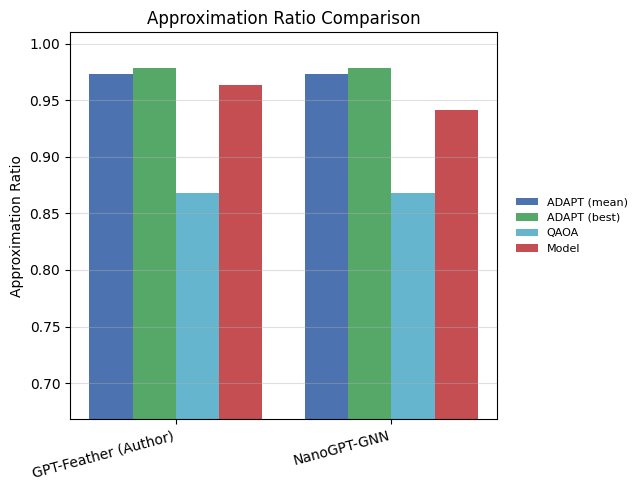

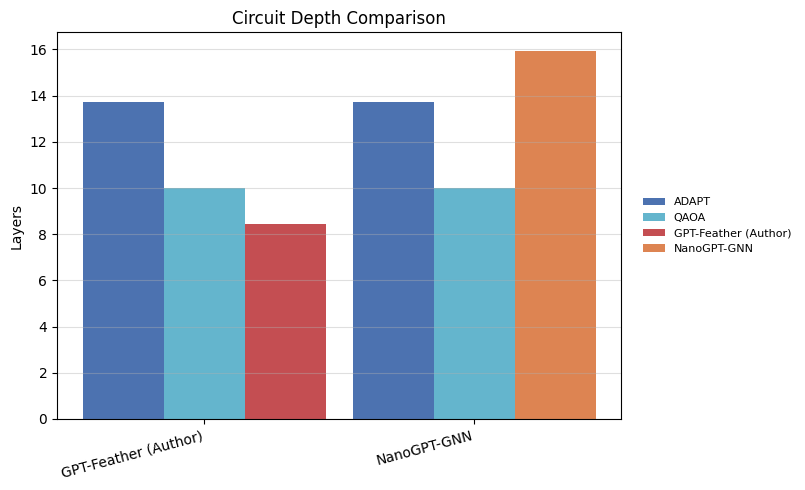

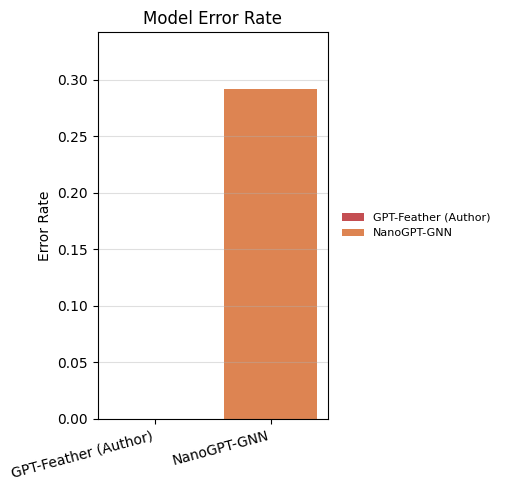

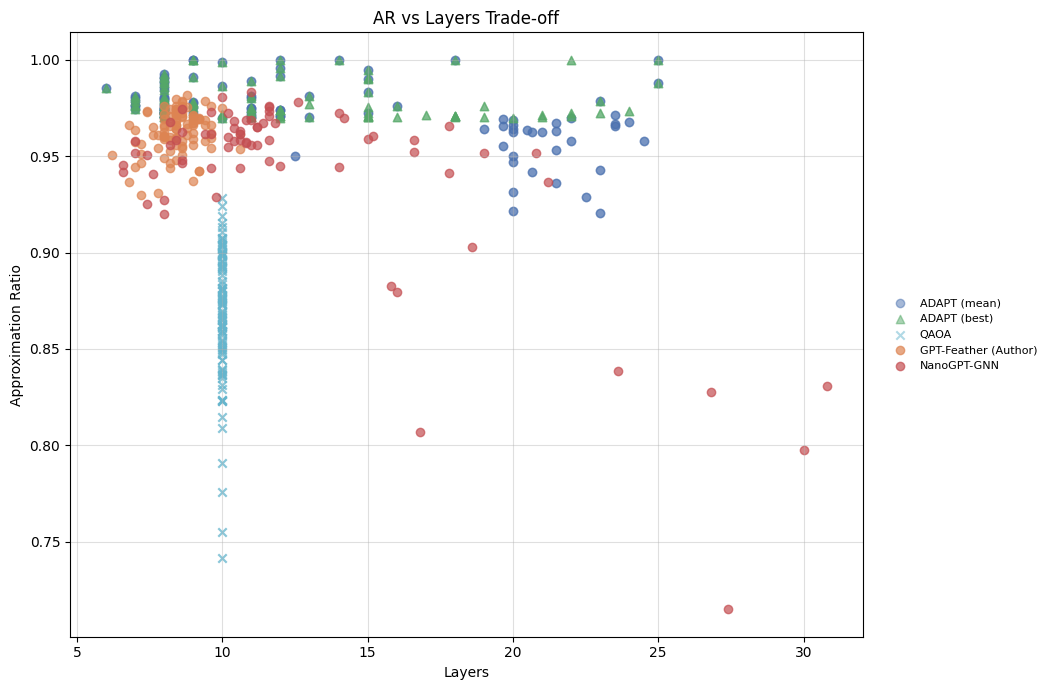

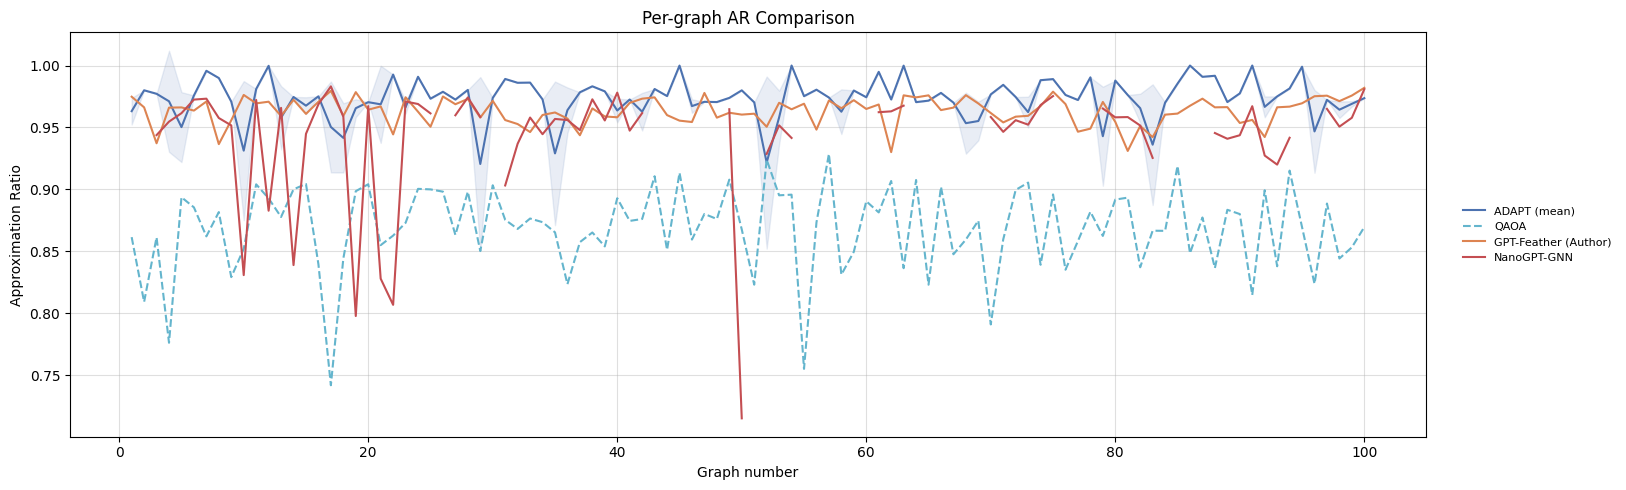

In [80]:
# ── Run all plots ──────────────────────────────────────────────────────────

plot_ar_bar(summary_df)
plot_layers_bar(summary_df)
plot_error_rate_bar(summary_df)
plot_ar_vs_layers_scatter(final_df)
plot_per_graph_ar(final_df)

# EXTRA INSIGHTS

In [82]:
# ------------------------
# EXTRA INSIGHTS (CLEAN)
# ------------------------

print("=" * 55)
print("INSIGHTS")
print("=" * 55)

for _, row in summary_df.iterrows():
    print(f"\nModel : {row['model']}")
    
    print(f"  ADAPT AR (mean / best): {row['adapt_ar_mean']:.4f} / {row['adapt_ar_best']:.4f}")
    print(f"  Model AR              : {row['model_ar']:.4f}")
    
    if "qaoa_ar_mean" in row:
        print(f"  QAOA AR (mean / best) : {row['qaoa_ar_mean']:.4f} / {row['qaoa_ar_best']:.4f}")
    
    print(f"  ADAPT layers (mean)   : {row['adapt_layers']:.2f}")
    print(f"  Model layers          : {row['model_layers']:.2f}")
    
    if "qaoa_layers" in row:
        print(f"  QAOA layers           : {row['qaoa_layers']:.2f}")
    
    print(f"  Model error rate      : {row['model_error_rate']:.4f}")
    
    if "qaoa_time_mean" in row:
        print(f"  QAOA time (mean)      : {row['qaoa_time_mean']:.2f}s")

INSIGHTS

Model : GPT-Feather (Author)
  ADAPT AR (mean / best): 0.9731 / 0.9788
  Model AR              : 0.9631
  QAOA AR (mean / best) : 0.8684 / 0.9149
  ADAPT layers (mean)   : 13.74
  Model layers          : 8.45
  QAOA layers           : 10.00
  Model error rate      : 0.0000
  QAOA time (mean)      : 88.78s

Model : NanoGPT-GNN
  ADAPT AR (mean / best): 0.9731 / 0.9788
  Model AR              : 0.9418
  QAOA AR (mean / best) : 0.8684 / 0.9149
  ADAPT layers (mean)   : 13.74
  Model layers          : 15.95
  QAOA layers           : 10.00
  Model error rate      : 0.2920
  QAOA time (mean)      : 88.78s
